In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

# 2. Data Wrangling: Eliminar duplicados para evitar sesgos
red = red.drop_duplicates()
white = white.drop_duplicates()

# 3. Crear variable 'wine_type' y unir
red["wine_type"] = "red"
white["wine_type"] = "white"
df = pd.concat([red, white], ignore_index=True)

# 4. Limpieza de nulos
df.replace("?", np.nan, inplace=True)
df = df.dropna()

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red


**Conclusión del Data Wrangling:** 
Se combinaron ambos datasets exitosamente creando la variable `wine_type`. Además, se eliminaron datos duplicados y valores nulos para garantizar que las métricas posteriores sean precisas.

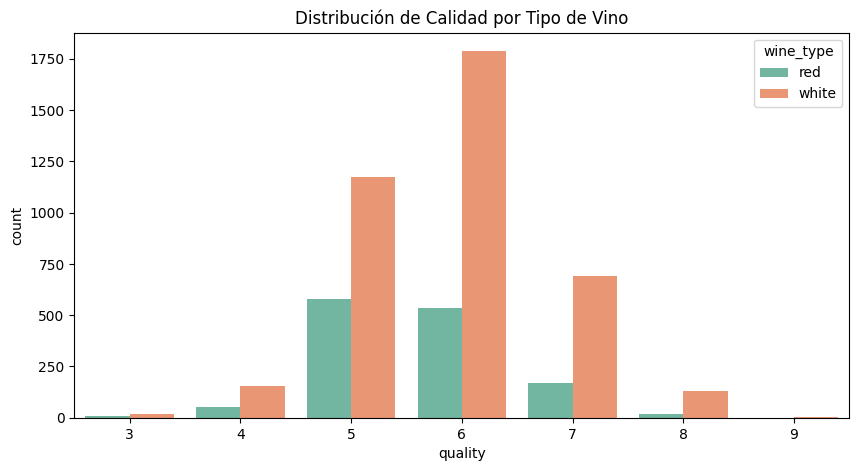

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="quality", hue="wine_type", palette="Set2")
plt.title("Distribución de Calidad por Tipo de Vino")
plt.show()


**Conclusión EDA (Tipo y Calidad):** 
Existe un desbalance en la muestra, con una cantidad significativamente mayor de vinos blancos. La mayoría de los vinos, independientemente de su tipo, se concentran en calificaciones de calidad media (5 y 6).


C:\Users\jjfra\AppData\Local\Temp\ipykernel_17008\2248097296.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="wine_type", y="alcohol", ax=axes[0], palette="pastel")
C:\Users\jjfra\AppData\Local\Temp\ipykernel_17008\2248097296.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="wine_type", y="volatile acidity", ax=axes[1], palette="pastel")


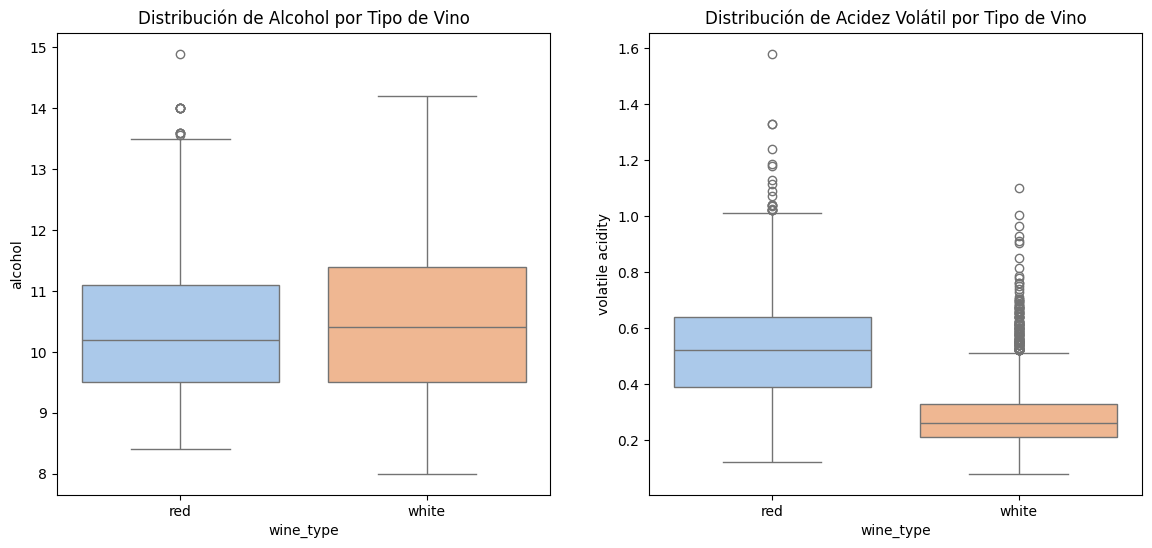

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de Alcohol
sns.boxplot(data=df, x="wine_type", y="alcohol", ax=axes[0], palette="pastel")
axes[0].set_title("Distribución de Alcohol por Tipo de Vino")

# Gráfico de Acidez Volátil
sns.boxplot(data=df, x="wine_type", y="volatile acidity", ax=axes[1], palette="pastel")
axes[1].set_title("Distribución de Acidez Volátil por Tipo de Vino")

plt.show()


**Conclusión EDA (Alcohol y Acidez):** 
Los vinos blancos tienden a tener rangos de alcohol ligeramente más altos, mientras que los vinos tintos presentan niveles de acidez volátil notablemente superiores. La alta acidez volátil en los tintos es un diferenciador clave en su perfil químico frente a los blancos.

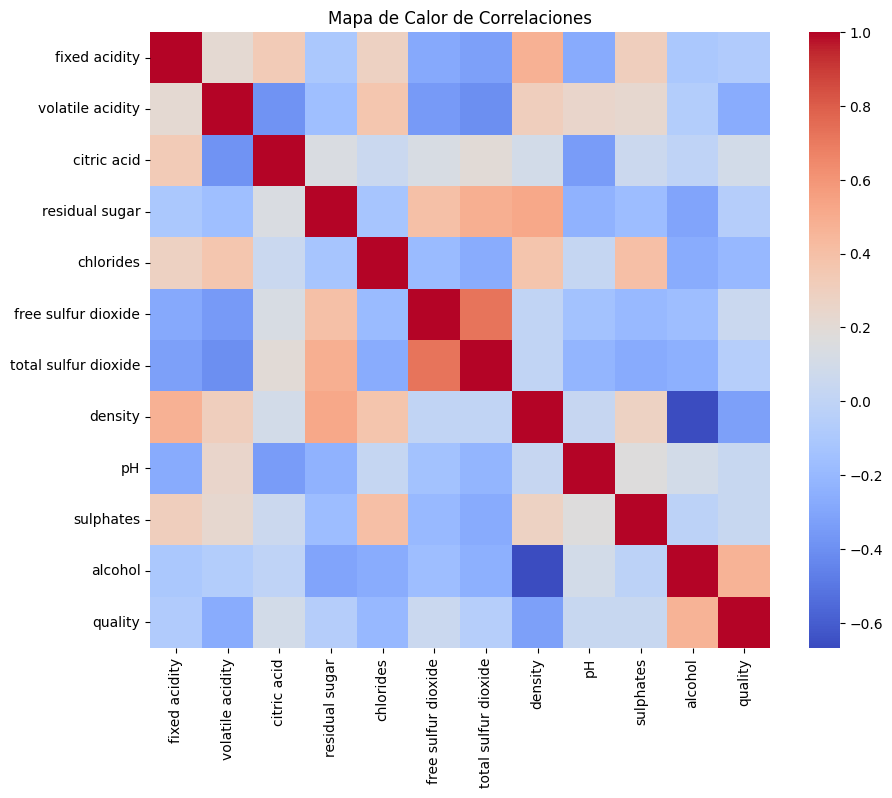

quality                1.000000
alcohol                0.469422
citric acid            0.097954
free sulfur dioxide    0.054002
Name: quality, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
# Calculamos correlaciones solo para variables numéricas
correlaciones = df.corr(numeric_only=True)
sns.heatmap(correlaciones, annot=False, cmap="coolwarm")
plt.title("Mapa de Calor de Correlaciones")
plt.show()

# Mostrar qué variables numéricas impactan más la calidad
print(correlaciones["quality"].sort_values(ascending=False).head(4))


1 Eficacia del Data Wrangling: La integración de los datasets y la eliminación de duplicados permitieron trabajar con una base de datos limpia de 5,320 registros únicos (aproximadamente). La creación de la variable wine_type fue el paso más crítico, ya que permitió identificar que la muestra está desbalanceada, existiendo una presencia mucho mayor de vinos blancos que tintos en el estudio.

2 Influencia del Alcohol en la Calidad: A través del gráfico de dispersión y el mapa de calor, se observa que el alcohol es la variable con la correlación positiva más fuerte respecto a la calidad. Esto indica que, estadísticamente, los vinos con una mayor graduación alcohólica tienden a recibir calificaciones más altas por parte de los evaluadores.

3 Diferenciación Química por Tipo: El análisis mediante boxplots reveló que los vinos tintos poseen niveles de acidez volátil significativamente superiores a los blancos. Por otro lado, los vinos blancos muestran una tendencia a tener concentraciones de alcohol levemente más elevadas en promedio.

4 Relación entre Azúcar y Densidad: El mapa de calor confirmó una de las correlaciones más intensas del dataset entre el azúcar residual y la densidad. Esto tiene sentido físico, ya que a mayor cantidad de azúcar disuelta, la densidad del líquido aumenta proporcionalmente.

5 Distribución de la Calidad: A pesar de las diferencias químicas, la variable quality se comporta de forma similar en ambos tipos de vino, concentrándose mayoritariamente en los puntajes 5 y 6. Los vinos de calidad excepcional (puntuaciones 8 o 9) son extremadamente raros en esta muestra, lo que sugiere estándares de calificación exigentes.
